#📌 Extracción

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
data = pd.read_json(url)
data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
customer = pd.json_normalize(data['customer'])
phone = pd.json_normalize(data['phone'])
internet = pd.json_normalize(data['internet'])
account = pd.json_normalize(data['account'])

df = pd.concat(
    [data[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### punto 2
#### Comprobación de incoherencias en los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [4]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [6]:
(df == " ").sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


### punto 3
#### Manejo de inconsistencias

In [7]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [8]:
df['Churn'] = df['Churn'].replace('', 'Desconocido')
df['Churn'] = df['Churn'].fillna('Desconocido')

In [9]:

(df['Charges.Total'] == " ").sum()

np.int64(11)

In [10]:
import numpy as np

df['Charges.Total'].replace(" ", np.nan, inplace=True)

/tmp/ipykernel_1434/4014385137.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charges.Total'].replace(" ", np.nan, inplace=True)


In [11]:
# Convertir 'charges.total' a numérico y rellenar los valores faltantes con la mediana
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].median())

In [12]:
df['Charges.Total'].isnull().sum()

np.int64(0)

### Punto 4
#### Creacion de columna cuentas diarias

In [13]:
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [15]:
df[['Charges.Monthly', 'Cuentas_Diarias']].head()
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


### PUNTO 5
#### Estandarización y transformación de datos

In [16]:
columns_binarias = [
    'Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'MultipleLines'
]



In [17]:
for i in columns_binarias:
    df[i] = df[i].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_1434/3655692285.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[i] = df[i].replace({'Yes': 1, 'No': 0})


In [18]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#🔧 Transformación

#📊 Carga y análisis

/tmp/ipykernel_1434/1823446641.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn_label', data=df_temp, palette=paleta, edgecolor='none')


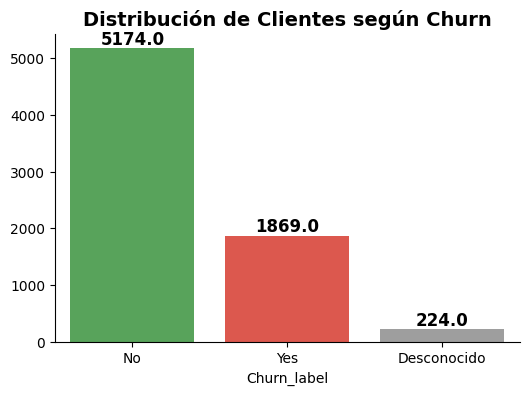

In [19]:
## Gráfica de distribución de 'Churn'
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
df_temp = df.copy()

df_temp['Churn_label'] = df_temp['Churn'].map({0:'No', 1:'Yes', 'Desconocido':'Desconocido'})
paleta = {'No': '#4CAF50', 'Yes': '#F44336', 'Desconocido': '#9E9E9E'}
ax = sns.countplot(x='Churn_label', data=df_temp, palette=paleta, edgecolor='none')
ax.set_ylabel('')
sns.despine()

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title("Distribución de Clientes según Churn", fontsize=14, fontweight='bold')

plt.show()

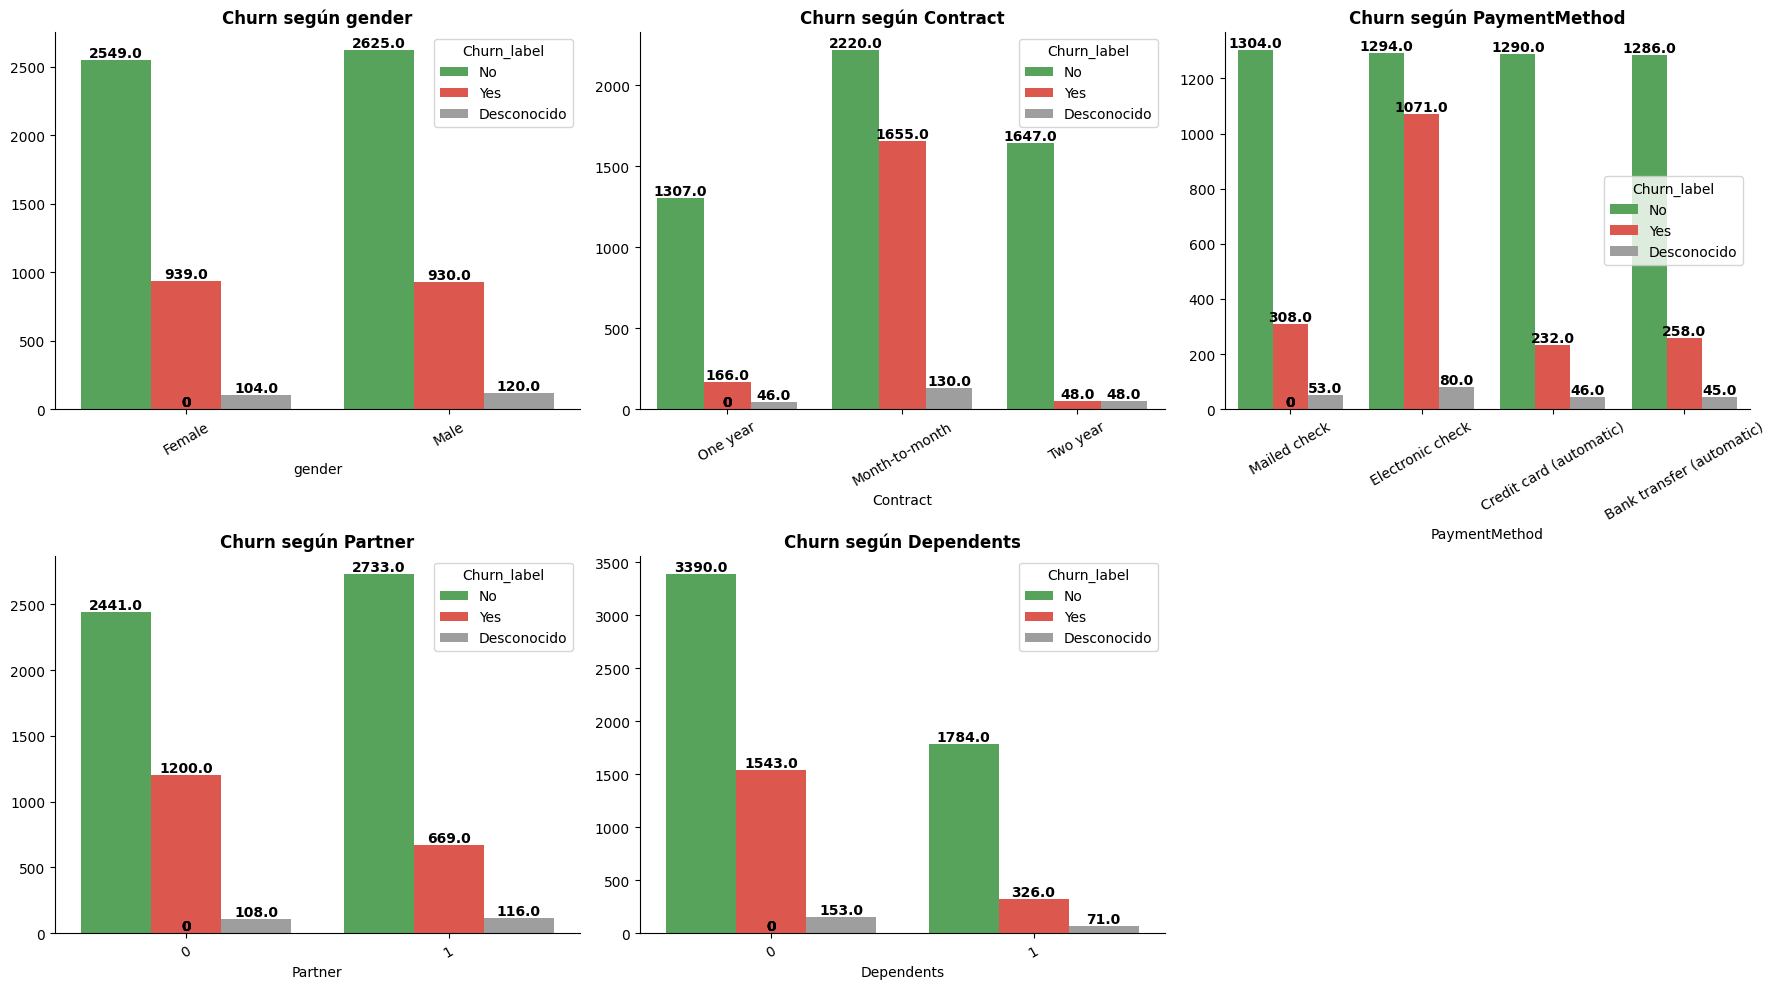

In [20]:
# Gráfica de 'Churn' por 'Contract'
import matplotlib.pyplot as plt
import seaborn as sns

categoricas = ['gender', 'Contract', 'PaymentMethod', 'Partner', 'Dependents']

df_temp = df.copy()

df_temp['Churn_label'] = df_temp['Churn'].map({0:'No', 1:'Yes', 'Desconocido':'Desconocido'})

paleta = {'No': '#4CAF50', 'Yes': '#F44336', 'Desconocido': '#9E9E9E'}

n_cols = 3
n_rows = (len(categoricas) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    ax = sns.countplot(x=col, hue='Churn_label', data=df_temp, palette=paleta, edgecolor='none', ax=axes[i])
    ax.set_ylabel('')
    ax.set_title(f"Churn según {col}", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1434/2454837331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn_label', y=col, data=df_temp, palette=paleta, ax=axes[i], inner='quartile')
/tmp/ipykernel_1434/2454837331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn_label', y=col, data=df_temp, palette=paleta, ax=axes[i], inner='quartile')
/tmp/ipykernel_1434/2454837331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn_label', y=col, data=df_temp, palette=paleta, ax=axes[i], inner='quartile')


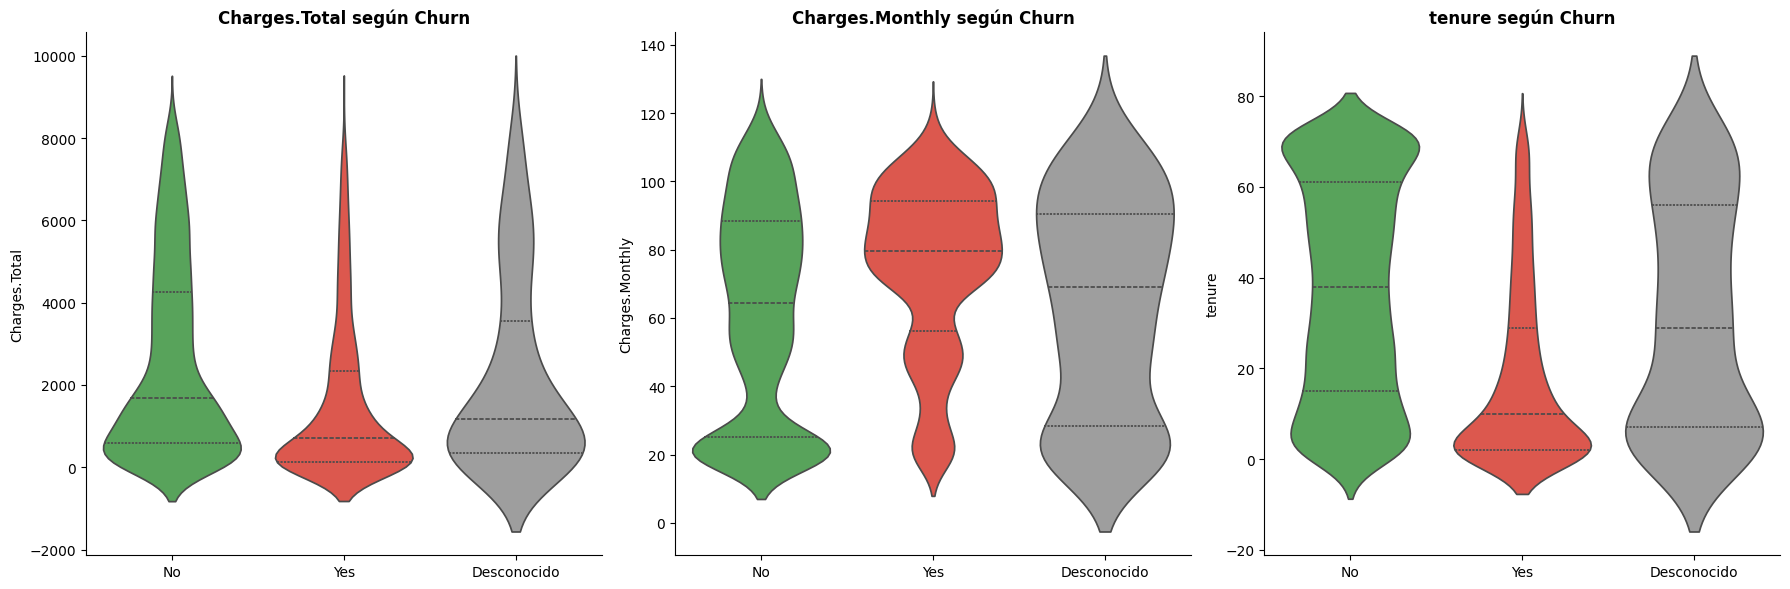

In [21]:
# Gráfica de variables numéricas por 'Churn'
import matplotlib.pyplot as plt
import seaborn as sns

numericas = ['Charges.Total', 'Charges.Monthly', 'tenure']

df_temp = df.copy()
df_temp['Churn_label'] = df_temp['Churn'].map({0:'No', 1:'Yes', 'Desconocido':'Desconocido'})

paleta = {'No': '#4CAF50', 'Yes': '#F44336', 'Desconocido': '#9E9E9E'}

fig, axes = plt.subplots(1, len(numericas), figsize=(18,6))

for i, col in enumerate(numericas):
    sns.violinplot(x='Churn_label', y=col, data=df_temp, palette=paleta, ax=axes[i], inner='quartile')
    axes[i].set_xlabel('')
    axes[i].set_title(f"{col} según Churn", fontsize=12, fontweight='bold')
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

#📄Informe final

### Conclusion
El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en Telecom X, con el fin de identificar patrones, comportamientos y posibles estrategias de retención. La empresa enfrenta una alta tasa de cancelaciones y requiere información estratégica para reducir pérdidas y fidelizar clientes.

El dataset analizado contiene información de los clientes de Telecom X, incluyendo datos demográficos, tipo de servicio contratado, historial de facturación, método de pago y duración del contrato. Esta información permite identificar correlaciones entre características de los clientes y la probabilidad de que abandonen el servicio.

#### **Limpieza y Tratamiento de Datos**

Para garantizar la calidad del análisis, se realizaron los siguientes pasos:

Carga y normalización del JSON: Los datos originales estaban en un formato anidado (customer, phone, internet, account). Se transformaron a un DataFrame plano para facilitar su manipulación.

**Valores faltantes:**

La columna Charges.Total presentaba algunos valores nulos. Estos se reemplazaron con la mediana de la columna para evitar distorsionar análisis posteriores.

La variable Churn contenía algunos valores desconocidos. Se clasificaron como Desconocido para poder mantenerlos visibles en los análisis sin perder información.

Estandarización de variables:

Se convirtieron valores binarios como Yes/No a un formato uniforme (Sí/No) donde correspondía, manteniendo la claridad para interpretación.

Se crearon indicadores claros para facilitar la interpretación de los resultados (por ejemplo, Cuentas_Diarias a partir de la facturación mensual).

Con estos pasos, el dataset quedó listo para el Análisis Exploratorio de Datos (EDA).

####  **Análisis Exploratorio de Datos**
#####   **Distribución general de Churn**

La mayoría de los clientes no cancelaron el servicio, mientras que una proporción significativa sí lo hizo.
Algunos registros permanecen como Desconocido, indicando clientes con información incompleta sobre su estado de cancelación.
Esto sugiere que el problema de churn está concentrado en un grupo relativamente pequeño de clientes.

#####  **Churn según variables categóricas**

Se analizaron las principales variables categóricas que podrían estar asociadas con la evasión:

*Tipo de contrato:*

Los clientes con contrato Month-to-month presentan la mayor tasa de cancelación.
Contratos de uno o dos años muestran una tasa de churn significativamente menor, lo que indica que la fidelización a largo plazo reduce la probabilidad de abandono.

*Género:*

No se observan diferencias sustanciales en la evasión entre clientes masculinos y femeninos. Esto indica que las estrategias de retención no requieren guiarse por género.

*Método de pago:*

Clientes que utilizan Electronic Check tienden a cancelar más que quienes usan métodos automáticos o pagos con cheque enviado por correo.

Esto sugiere que incentivar métodos de pago automáticos podría mejorar la retención.

#####  **Churn según variables numéricas**

Se evaluaron variables continuas para identificar correlaciones con la evasión:

Tiempo de contrato (tenure):
Clientes con menor tiempo de permanencia tienen mayor probabilidad de churn. Esto indica la importancia de estrategias de retención tempranas, especialmente durante los primeros meses de servicio.

Gasto mensual y total (Charges.Monthly y Charges.Total):
Clientes con menor gasto total tienden a cancelar con mayor frecuencia. Sin embargo, algunos clientes con gasto elevado también abandonan, lo que sugiere problemas de satisfacción con el servicio más allá del valor monetario.

Servicios adicionales:
La contratación de servicios adicionales como Online Security, Tech Support o Device Protection parece asociarse a menor churn, indicando que clientes más comprometidos con el ecosistema de la empresa son más leales.

#### **Conclusiones e Insights**

Mayor riesgo de churn:

-Clientes con contrato Month-to-month.
-Clientes con poco tiempo de permanencia.
-Clientes que usan Electronic Check como método de pago.
-Factores que reducen el churn:
-Contratos a largo plazo (1 o 2 años).
-Contratación de servicios adicionales, que incrementa el compromiso con la empresa.
-Clientes con mayor gasto total mensual o anual, que perciben valor en el servicio.

Variables irrelevantes o poco influyentes:

-Género del cliente.
-Algunos servicios básicos que todos contratan (como Phone Service).

#### **Recomendaciones estratégicas**

Fidelización temprana: Implementar campañas de retención durante los primeros 3-6 meses de servicio para clientes con contratos cortos.

Incentivos para contratos largos: Ofrecer descuentos, beneficios exclusivos o paquetes adicionales para motivar a los clientes a firmar contratos de 1 o 2 años.

Optimización de métodos de pago: Promover el uso de métodos automáticos que históricamente muestran menor churn.

Cross-selling de servicios adicionales: Ofrecer servicios de seguridad, soporte y protección de dispositivos a clientes nuevos y en riesgo de churn.

Segmentación de campañas: Enfocar esfuerzos en clientes con menor tiempo de permanencia y menor gasto total, ya que representan el segmento de mayor riesgo.

